# Audio Codec Inspection Pipeline

## Setup and Imports

In [1]:
using Flux
using BSON
using Random
using Plots
using Statistics

include("src/data.jl")
include("src/preprocess.jl")
include("src/quantizer.jl")
include("src/dataset.jl")
include("src/dataloader.jl")
include("src/model.jl")
include("src/metric_calc.jl")

using .Data
using .Preprocess
using .Quantizer
using .Dataset
using .Model
using .Metric_Calc

## Load Model

In [2]:
model_data = BSON.load("best_model.bson")
model = haskey(model_data, :model) ? model_data[:model] : model_data[:model_cpu]
Flux.testmode!(model)
println("Model loaded successfully")

Model loaded successfully


## Load Random Test Audio

In [3]:
audio_files = Data.list_librispeech_flac("."; split="test-clean")
random_idx = rand(1:length(audio_files))
audio_path = audio_files[random_idx]
sample_audio = Data.load_audio(audio_path)
sample_id = basename(dirname(audio_path)) * "/" * basename(audio_path)

println("Loaded sample: ", sample_id)
println("Audio length: ", length(sample_audio), " samples")
println("Duration: ", length(sample_audio) / Data.SAMPLE_RATE, " seconds")

Loaded sample: 28241/5105-28241-0017.flac
Audio length: 204080 samples
Duration: 12.755 seconds


## Input Mel-Spectrogram (Normalized)

Mel shape: (80, 1024)
Mel range: [-23.02585, 3.2244425]


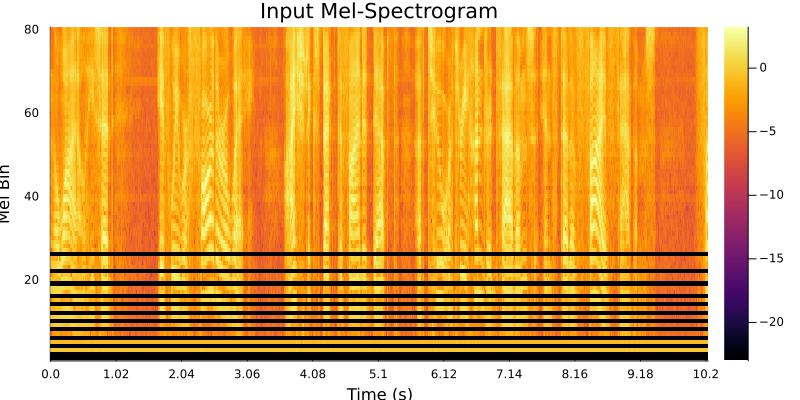

In [4]:
mel = Data.logmel(sample_audio)
mel_fixed = Preprocess.fix_length(mel)
mel_flat = reshape(mel_fixed, :, 1, 1)

println("Mel shape: ", size(mel_fixed))
println("Mel range: [", minimum(mel_fixed), ", ", maximum(mel_fixed), "]")

audio_duration_sec = length(sample_audio) / Data.SAMPLE_RATE
n_frames_actual = Int(ceil(audio_duration_sec * Data.SAMPLE_RATE / Data.HOP_LENGTH))
n_frames_actual = min(n_frames_actual, size(mel_fixed, 2))

mel_actual = mel_fixed[:, 1:n_frames_actual]
time_axis = (0:n_frames_actual-1) .* Data.HOP_LENGTH ./ Data.SAMPLE_RATE

heatmap(mel_actual, 
    title="Input Mel-Spectrogram",
    xlabel="Time (s)",
    ylabel="Mel Bin",
    colorbar=true,
    aspect_ratio=:auto,
    xticks=(1:max(1,n_frames_actual÷10):n_frames_actual, round.(time_axis[1:max(1,n_frames_actual÷10):n_frames_actual], digits=2)),
    size=(800, 400))

## Decode to Reconstructed Mel-Spectrogram

Reconstructed mel shape: (80, 1024)
Reconstructed mel range: [-26.455893, -1.2081348]


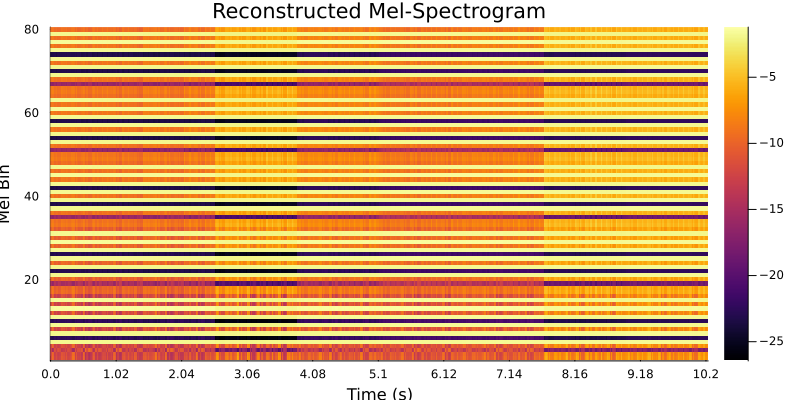

In [6]:
recon_flat = model(mel_flat)
recon_mel_full = reshape(recon_flat[:, 1, 1], size(mel_fixed))
recon_mel = recon_mel_full[:, 1:n_frames_actual]

println("Reconstructed mel shape: ", size(recon_mel))
println("Reconstructed mel range: [", minimum(recon_mel), ", ", maximum(recon_mel), "]")

heatmap(recon_mel,
    title="Reconstructed Mel-Spectrogram",
    xlabel="Time (s)",
    ylabel="Mel Bin",
    colorbar=true,
    aspect_ratio=:auto,
    xticks=(1:max(1,n_frames_actual÷10):n_frames_actual, round.(time_axis[1:max(1,n_frames_actual÷10):n_frames_actual], digits=2)),
    size=(800, 400))

## Comparison: Input vs Reconstructed

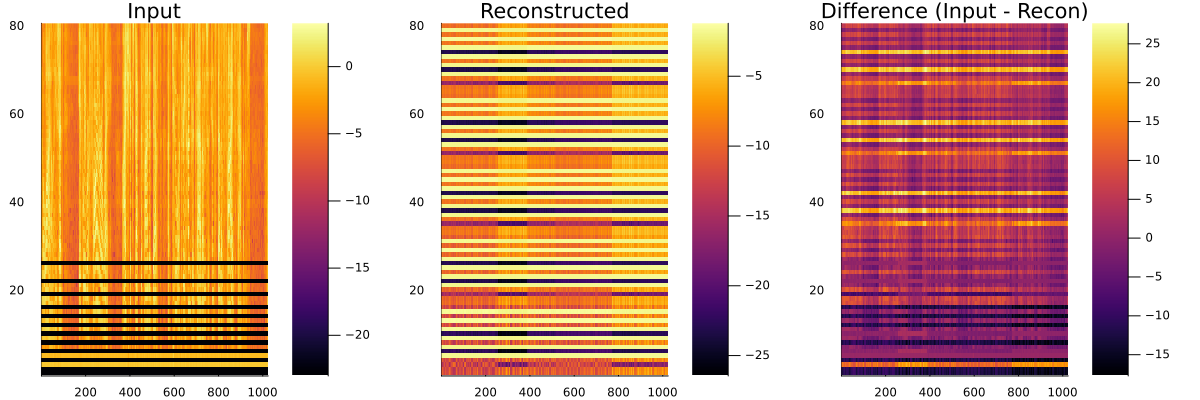

In [7]:
p1 = heatmap(mel_actual, title="Input", colorbar=true, size=(400, 300))
p2 = heatmap(recon_mel, title="Reconstructed", colorbar=true, size=(400, 300))
p3 = heatmap(mel_actual .- recon_mel, title="Difference (Input - Recon)", colorbar=true, size=(400, 300))

plot(p1, p2, p3, layout=(1, 3), size=(1200, 400))

## Waveform Reconstruction and Metrics

In [8]:
input_audio = Data.griffin_lim(mel_actual)
recon_audio = Data.griffin_lim(recon_mel)

min_len = min(length(input_audio), length(recon_audio))
orig = input_audio[1:min_len]
recon = recon_audio[1:min_len]

mse = Metric_Calc.compute_mse(orig, recon)
snr = Metric_Calc.compute_snr(orig, recon)
pesq = Metric_Calc.estimate_pesq(orig, recon)
stoi = Metric_Calc.estimate_stoi(orig, recon)

audio_duration_sec = Float32(length(sample_audio) / Data.SAMPLE_RATE)
indices_int = Int.(clamp.(round.(indices), 1, typemax(Int)))

println("Indices stats: min=", minimum(indices_int), " max=", maximum(indices_int), " length=", length(indices_int))

if maximum(indices_int) > 0
    bits_per_code = ceil(Int, log2(maximum(indices_int)))
    total_bits = length(indices_int) * bits_per_code
    bitrate = Float32(total_bits / audio_duration_sec / 1000.0f0)
else
    bitrate = 0.0f0
end

println("\n======== Metrics =========")
println("MSE: ", mse)
println("SNR: ", snr, " dB")
println("PESQ (estimated): ", pesq)
println("STOI (estimated): ", stoi)
println("Bitrate: ", bitrate, " kbps")

Indices stats: min=1 max=1 length=5120

======== Metrics =========
MSE: 0.004652421
SNR: -0.02882994 dB
PESQ (estimated): 4.4658957
STOI (estimated): 0.49753416
Bitrate: 0.0 kbps


## Waveform Comparison

In [9]:
signal_power = mean(orig .^ 2)
noise_power = mse
snr_manual = 10 * log10(signal_power / noise_power)

println("\n=== SNR Breakdown ===")
println("Original signal amplitude range: [", minimum(orig), ", ", maximum(orig), "]")
println("Signal power: ", signal_power)
println("Noise power (MSE): ", noise_power)
println("SNR (manual calc): ", snr_manual, " dB")
println("\nInterpretation: Noise power is ", round(100 * noise_power / signal_power, digits=1), "% of signal power!")


=== SNR Breakdown ===


Original signal amplitude range: [-0.9968391, 0.98242706]
Signal power: 0.004621639
Noise power (MSE): 0.004652421
SNR (manual calc): -0.02882994 dB

Interpretation: Noise power is 100.7% of signal power!


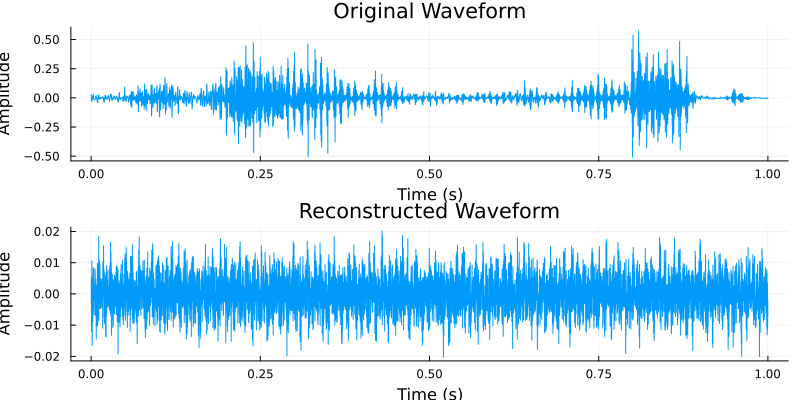

In [10]:
sample_points = min(16000, length(orig))
time_axis = (1:sample_points) ./ Data.SAMPLE_RATE

p1 = plot(time_axis, orig[1:sample_points], 
    title="Original Waveform", 
    xlabel="Time (s)", 
    ylabel="Amplitude",
    legend=false,
    size=(800, 200))

p2 = plot(time_axis, recon[1:sample_points], 
    title="Reconstructed Waveform",
    xlabel="Time (s)",
    ylabel="Amplitude",
    legend=false,
    size=(800, 200))

plot(p1, p2, layout=(2, 1), size=(800, 400))

## Save Audio Files for Playback

In [11]:
using WAV

orig_normalized = orig ./ maximum(abs.(orig))
recon_normalized = recon ./ maximum(abs.(recon))

wavwrite(orig_normalized, "input_audio.wav", Fs=Int(Data.SAMPLE_RATE))
wavwrite(recon_normalized, "reconstructed_audio.wav", Fs=Int(Data.SAMPLE_RATE))

println("Audio files saved:")
println("input_audio.wav (Griffin-Lim from original mel)")
println("reconstructed_audio.wav (Griffin-Lim from model output)")

Audio files saved:
input_audio.wav (Griffin-Lim from original mel)
reconstructed_audio.wav (Griffin-Lim from model output)


## Playback Audio in Notebook

In [12]:
using Base64

function audio_player(filename::String, label::String)
    audio_data = read(filename)
    b64_audio = base64encode(audio_data)
    html = """
    <div style="margin: 10px 0;">
        <strong>$label</strong><br/>
        <audio controls>
            <source src="data:audio/wav;base64,$b64_audio" type="audio/wav">
            Your browser does not support the audio element.
        </audio>
    </div>
    """
    display("text/html", html)
end

audio_player("input_audio.wav", "Input Audio (Original Mel → Griffin-Lim)")
audio_player("reconstructed_audio.wav", "Reconstructed Audio (Model Output → Griffin-Lim)")

Input Audio (Original Mel → Griffin-Lim) 
 
 
 Your browser does not support the audio element.

Reconstructed Audio (Model Output → Griffin-Lim) 
 
 
 Your browser does not support the audio element.